In [5]:
# 1. 导入核心库
import os
os.environ['UNSLOTH_USE_MODELSCOPE'] = '1'  # 必须在导入 Unsloth 之前设置！
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
import torch
from datasets import load_dataset
from transformers import TrainingArguments
from trl import SFTTrainer
from unsloth import FastLanguageModel, is_bfloat16_supported


/root/miniconda3/envs/agiclass/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
/tmp/ipykernel_37707/2932254902.py:9: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel, is_bfloat16_supported


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [6]:
import sys
print(sys.executable)

/root/miniconda3/envs/agiclass/bin/python


In [7]:
model_name = "/root/autodl-tmp/DeepSeek-R1-Distill-Qwen-7B" # 或者直接用官方名称
max_seq_length = 2048  # 古诗词一句通常较短，2048足够覆盖整首

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    max_seq_length=max_seq_length,
    dtype=None,  # 自动选择最佳数据类型（通常为float16或bfloat16）
    load_in_4bit=True,  # 必须为True，开启4-bit加载
    use_gradient_checkpointing="unsloth",   # 开启 Unsloth 梯度检查点
    device_map="auto",  # 显式设置 device_map
)

==((====))==  Unsloth 2026.4.6: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4090. Num GPUs = 1. Max memory: 23.516 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 339/339 [00:03<00:00, 107.25it/s]


/root/autodl-tmp/DeepSeek-R1-Distill-Qwen-7B does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [8]:
# --- 原理拆解 ---
# get_peft_model 为模型挂载 LoRA 适配器。
# 参数解释：
# - r (rank): LoRA矩阵的秩。r=16意味着两个小矩阵尺寸为(d_model, 16)和(16, d_model)。
#   这是性能和效果的最佳平衡点。r越大，表达能力越强，但过拟合风险增加。
# - target_modules: 指定在哪些层的哪些投影矩阵上挂载适配器。
#   对于Qwen2架构，推荐包含 attention 和 MLP 的全部线性层，效果最好。
# - lora_alpha: 缩放因子，通常设为r的2倍或相同。
# - use_gradient_checkpointing: 用时间换空间，进一步节省显存。

model = FastLanguageModel.get_peft_model(
    model,
    r=16,  # LoRA秩
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",  # 注意力机制的Q/K/V/O投影
        "gate_proj", "up_proj", "down_proj"      # MLP层的三个投影矩阵
    ],
    lora_alpha=16,
    lora_dropout=0,  # DAPT阶段不需要Dropout，避免丢失信息
    bias="none",
    use_gradient_checkpointing="unsloth",  # Unsloth优化的检查点，更省显存
    random_state=42,
)


Unsloth 2026.4.6 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [9]:
# 查看可训练参数量（应该只有几十MB，远小于7B全量的14GB）
print("可训练参数统计：")
model.print_trainable_parameters()

可训练参数统计：
trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


In [10]:
def formatting_func(example):
    # 将诗句列表拼接，用换行符分隔，保持诗歌的段落感
    text = "\n".join(example["content"])
    # 在末尾添加eos_token，告诉模型一首诗结束
    return {"text": text + tokenizer.eos_token}

# 加载数据集
dataset = load_dataset("json", data_files="chuci.json", split="train")
dataset = dataset.map(formatting_func, remove_columns=["title", "section", "author", "content"])
dataset = dataset.train_test_split(test_size=0.05, seed=42)  # 5%作验证集
train_dataset = dataset["train"]
eval_dataset = dataset["test"]

print(f"训练集样本数: {len(train_dataset)}")
print(f"验证集样本数: {len(eval_dataset)}")


Generating train split: 65 examples [00:00, 3145.90 examples/s]
Map: 100%|██████████| 65/65 [00:00<00:00, 6692.44 examples/s]

训练集样本数: 61
验证集样本数: 4


In [11]:
# --- 原理拆解 ---
# TrainingArguments 控制训练的所有超参数。
# 关键点：
# - learning_rate: 必须小！DAPT推荐1e-5~5e-5。我们取3e-5。
# - per_device_train_batch_size: 根据显存调整。4 对24GB显存是安全的。
# - gradient_accumulation_steps: 4 意味着每4步更新一次权重，等效batch_size = 4*4 = 16。
# - max_steps: 控制总训练步数。计算方式：样本数 / 等效batch_size * 轮数。假设2万样本，等效batch=16，1轮≈1250步。我们设2000步，约1.6轮。
# - warmup_steps: 学习率预热，前100步学习率从0线性增长到设定值，稳定训练。
# - fp16/bf16: 混合精度训练，加速且省显存。

training_args = TrainingArguments(
    output_dir="./poetry-dapt-output",       # 输出目录
    per_device_train_batch_size=4,           # 单卡训练批次大小
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,           # 梯度累积步数
    warmup_steps=100,
    max_steps=2000,                          # 总训练步数
    learning_rate=3e-5,                      # 核心参数：务必小！
    fp16=not is_bfloat16_supported(),        # 若GPU不支持BF16则用FP16
    bf16=is_bfloat16_supported(),
    logging_steps=25,                        # 每25步打印一次loss
    save_steps=200,                          # 每200步保存一次checkpoint
    eval_steps=200,                          # 每200步在验证集上评估
    eval_strategy="steps",
    save_total_limit=3,                      # 只保留最近3个checkpoint
    load_best_model_at_end=True,             # 训练结束加载最优模型
    report_to="tensorboard",                 # 推荐使用TensorBoard监控
    seed=42,
)


In [12]:
from RealTimeMonitor import RealTimeMonitor
# 创建监控器
realtime_monitor = RealTimeMonitor()

In [13]:
from trl import SFTTrainer, SFTConfig

# ... (之前的模型、tokenizer、数据集等代码保持不变)

sft_config = SFTConfig(
    output_dir="./output",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    max_seq_length=2048,
    dataset_text_field="text",
    packing=False,
    dataset_num_proc=2,
    logging_steps=10,
    # 关键：启用评估策略
    eval_strategy="steps",          # 或 "epoch"
    eval_steps=100,                 # 每100步评估一次
    save_strategy="steps",          # 与 eval_strategy 保持一致
    save_steps=100,                 # 每100步保存一次
    save_total_limit=2,
    load_best_model_at_end=True,    # 需要评估才能找到最佳模型
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=False,      # 关闭 float16
    bf16=True,       # 开启 bfloat16
)

In [14]:
# --- 原理拆解 ---
# SFTTrainer 是 trl 库提供的监督微调训练器，但对自回归任务同样适用。
# 关键参数：
# - dataset_text_field: 指定数据集中哪个字段包含文本。
# - packing: 是否将多个短文本打包进一个序列以提升效率。由于古诗长短不一，设为False避免混乱。
# - max_seq_length: 必须与模型加载时一致。

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    callbacks=[realtime_monitor],
)


Unsloth: Tokenizing ["text"] (num_proc=2): 100%|██████████| 4/4 [00:01<00:00,  3.78 examples/s]


训练初始化完成，开始监控...
🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


<Figure size 640x480 with 0 Axes>

当前训练步数: 40
最新训练损失: 5.6982
最新验证损失: 5.2310


Step,Training Loss,Validation Loss
48,5.698208,5.230969


Epoch 3.0 完成，最新损失: 5.6982
训练完成！
训练图表已保存为 'training_final.png'
✅ 训练完成！


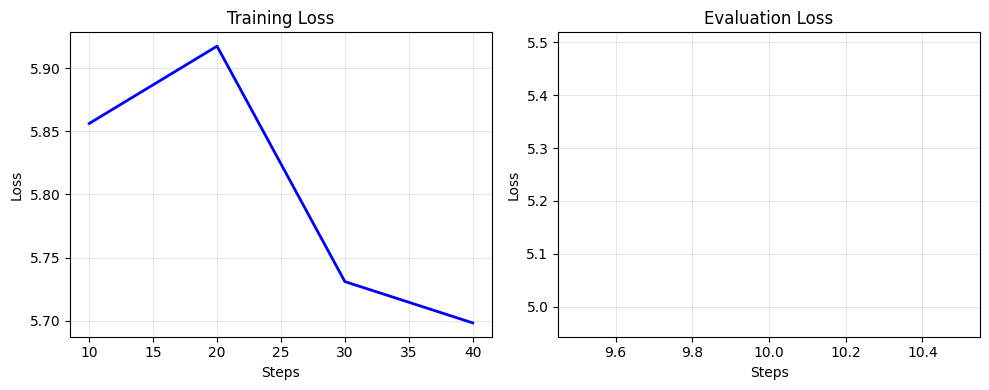

In [15]:
# 开始训练！
print("🚀 开始领域适应预训练...")
trainer.train()
print("✅ 训练完成！")


In [19]:
import os
print("当前工作目录:", os.getcwd())

当前工作目录: /root/dapt


In [21]:
# 保存LoRA适配器权重（体积很小，只有几十MB）
model.save_pretrained("poetry-dapt-lora-adapter")
tokenizer.save_pretrained("poetry-dapt-lora-adapter")

('poetry-dapt-lora-adapter/tokenizer_config.json',
 'poetry-dapt-lora-adapter/chat_template.jinja',
 'poetry-dapt-lora-adapter/tokenizer.json')

In [22]:
from unsloth import FastLanguageModel

# 加载微调后的模型（合并或仅适配器）
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="poetry-dapt-lora-adapter",  # 或者合并后的路径
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)


==((====))==  Unsloth 2026.4.6: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4090. Num GPUs = 1. Max memory: 23.516 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 339/339 [00:03<00:00, 112.04it/s]


/root/autodl-tmp/DeepSeek-R1-Distill-Qwen-7B does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [23]:
def generate_continuation(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [24]:
print(generate_continuation("帝高阳之苗裔兮，"))

Both `max_new_tokens` (=50) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/root/miniconda3/envs/agiclass/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/root/miniconda3/envs/agiclass/lib/python3.11/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, 

帝高阳之苗裔兮，太古玄黄之母女兮，若夫天地初开，混沌未分，盘根错节，错综成网，盘蛇出地，盘龙入海，盘丝入间，盘网入泉，盘
